In [21]:
# IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)

plt.style.use('ggplot')


In [22]:
# LOAD DATASET

file_path = r"./dataset/waqi-covid19-airqualitydata-2026Q2.csv"

df = pd.read_csv(
    file_path,
    skiprows=4
)

print("\nFIRST 5 ROWS")
display(df.head())

print("\nDATASET SHAPE")
print(df.shape)

print("\nCOLUMN NAMES")
print(df.columns)

print("\nMISSING VALUES")
print(df.isnull().sum())


FIRST 5 ROWS


,Date,Country,City,Specie,count,min,max,median,variance
0,2026-04-23,EE,Tallinn,temperature,72,3.0,7.5,5.0,28.15
1,2026-04-30,EE,Tallinn,temperature,72,3.0,12.0,6.5,105.84
2,2026-04-06,EE,Tallinn,temperature,72,2.0,5.0,3.0,4.61
3,2026-04-12,EE,Tallinn,temperature,72,-2.0,12.5,7.0,247.39
4,2026-04-21,EE,Tallinn,temperature,69,1.0,13.0,8.5,175.59



DATASET SHAPE
(262260, 9)

COLUMN NAMES
Index(['Date', 'Country', 'City', 'Specie', 'count', 'min', 'max', 'median',
       'variance'],
      dtype='str')

MISSING VALUES
Date        0
Country     0
City        0
Specie      0
count       0
min         0
max         0
median      0
variance    0
dtype: int64


In [23]:
# DATA CLEANING

df.drop_duplicates(inplace=True)

df.columns = df.columns.str.strip().str.lower()

for col in df.columns:

    if df[col].dtype == 'object':

        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
            .str.lower()
        )

print("\nDATA CLEANING COMPLETED")
display(df.head())


DATA CLEANING COMPLETED


,date,country,city,specie,count,min,max,median,variance
0,2026-04-23,EE,Tallinn,temperature,72,3.0,7.5,5.0,28.15
1,2026-04-30,EE,Tallinn,temperature,72,3.0,12.0,6.5,105.84
2,2026-04-06,EE,Tallinn,temperature,72,2.0,5.0,3.0,4.61
3,2026-04-12,EE,Tallinn,temperature,72,-2.0,12.5,7.0,247.39
4,2026-04-21,EE,Tallinn,temperature,69,1.0,13.0,8.5,175.59


In [24]:
# DATE CONVERSION

if 'date' in df.columns:

    df['date'] = pd.to_datetime(
        df['date'],
        errors='coerce'
    )

print("\nDATE CONVERSION COMPLETED")


DATE CONVERSION COMPLETED


In [25]:
# HANDLE MISSING VALUES

numeric_cols = df.select_dtypes(
    include=np.number
).columns

for col in numeric_cols:

    df[col].fillna(
        df[col].median(),
        inplace=True
    )

print("\nMISSING VALUES HANDLED")


MISSING VALUES HANDLED


C:\Users\gowth\AppData\Local\Temp\ipykernel_29512\4053616366.py:9: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(
C:\Users\gowth\AppData\Local\Temp\ipykernel_29512\4053616366.py:9: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such in

In [26]:
# LABEL ENCODING

categorical_cols = df.select_dtypes(
    include=['object']
).columns

encoder = LabelEncoder()

for col in categorical_cols:

    df[col] = encoder.fit_transform(
        df[col].astype(str)
    )

print("\nLABEL ENCODING COMPLETED")
display(df.head())


LABEL ENCODING COMPLETED


C:\Users\gowth\AppData\Local\Temp\ipykernel_29512\2091968072.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(


,date,country,city,specie,count,min,max,median,variance
0,2026-04-23,17,438,12,72,3.0,7.5,5.0,28.15
1,2026-04-30,17,438,12,72,3.0,12.0,6.5,105.84
2,2026-04-06,17,438,12,72,2.0,5.0,3.0,4.61
3,2026-04-12,17,438,12,72,-2.0,12.5,7.0,247.39
4,2026-04-21,17,438,12,69,1.0,13.0,8.5,175.59


In [27]:
# FEATURE SELECTION

target_column = 'median'

X = df.drop(columns=[target_column])

if 'date' in X.columns:

    X = X.drop(columns=['date'])

y = df[target_column]

print("\nFEATURES")
display(X.head())

print("\nTARGET")
display(y.head())


FEATURES


,country,city,specie,count,min,max,variance
0,17,438,12,72,3.0,7.5,28.15
1,17,438,12,72,3.0,12.0,105.84
2,17,438,12,72,2.0,5.0,4.61
3,17,438,12,72,-2.0,12.5,247.39
4,17,438,12,69,1.0,13.0,175.59



TARGET


0    5.0
1    6.5
2    3.0
3    7.0
4    8.5
Name: median, dtype: float64

In [28]:
# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTRAINING DATA SIZE")
print(X_train.shape)

print("\nTESTING DATA SIZE")
print(X_test.shape)


TRAINING DATA SIZE
(209808, 7)

TESTING DATA SIZE
(52452, 7)


In [29]:
# LINEAR REGRESSION

lr_model = LinearRegression()

lr_model.fit(
    X_train,
    y_train
)

lr_pred = lr_model.predict(X_test)

print("\nLINEAR REGRESSION TRAINED")


LINEAR REGRESSION TRAINED


In [30]:
# DECISION TREE

dt_model = DecisionTreeRegressor(
    random_state=42
)

dt_model.fit(
    X_train,
    y_train
)

dt_pred = dt_model.predict(X_test)

print("\nDECISION TREE TRAINED")


DECISION TREE TRAINED


In [31]:

# RANDOM FOREST

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(X_test)

print("\nRANDOM FOREST TRAINED")


RANDOM FOREST TRAINED


In [32]:
# REGRESSION EVALUATION

def evaluate_model(name, y_true, y_pred):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_true,
        y_pred
    )

    print(f"\n{name} RESULTS")

    print("MAE :", mae)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("R2  :", r2)

    return r2

lr_r2 = evaluate_model(
    "Linear Regression",
    y_test,
    lr_pred
)

dt_r2 = evaluate_model(
    "Decision Tree",
    y_test,
    dt_pred
)

rf_r2 = evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
)


Linear Regression RESULTS
MAE : 5.282978131935524
MSE : 454.03402185290867
RMSE: 21.308074100042656
R2  : 0.9947163023283256

Decision Tree RESULTS
MAE : 3.306118927781591
MSE : 90.07793393642442
RMSE: 9.490939570791946
R2  : 0.9989517424974745

Random Forest RESULTS
MAE : 2.5017585199438575
MSE : 48.595768467116855
RMSE: 6.971066522930108
R2  : 0.9994344799368666


In [ ]:
# CONVERT TO CLASSES

def classify_pollution(value):

    if value <= 50:
        return 0

    elif value <= 100:
        return 1

    else:
        return 2

y_test_class = y_test.apply(
    classify_pollution
)

lr_pred_class = pd.Series(lr_pred).apply(
    classify_pollution
)

dt_pred_class = pd.Series(dt_pred).apply(
    classify_pollution
)

rf_pred_class = pd.Series(rf_pred).apply(
    classify_pollution
)

print("\nCLASSIFICATION CONVERSION COMPLETED")


CLASSIFICATION CONVERSION COMPLETED


In [34]:
# ACCURACY SCORES

lr_acc = accuracy_score(
    y_test_class,
    lr_pred_class
)

dt_acc = accuracy_score(
    y_test_class,
    dt_pred_class
)

rf_acc = accuracy_score(
    y_test_class,
    rf_pred_class
)

print("\nLINEAR REGRESSION ACCURACY :", lr_acc)

print("DECISION TREE ACCURACY :", dt_acc)

print("RANDOM FOREST ACCURACY :", rf_acc)


LINEAR REGRESSION ACCURACY : 0.9674940898345153
DECISION TREE ACCURACY : 0.9716312056737588
RANDOM FOREST ACCURACY : 0.977255395409136


In [35]:
# CLASSIFICATION REPORT

print("\nRANDOM FOREST CLASSIFICATION REPORT\n")

print(
    classification_report(
        y_test_class,
        rf_pred_class
    )
)


RANDOM FOREST CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     40941
           1       0.90      0.91      0.90      6024
           2       0.98      0.99      0.98      5487

    accuracy                           0.98     52452
   macro avg       0.96      0.96      0.96     52452
weighted avg       0.98      0.98      0.98     52452



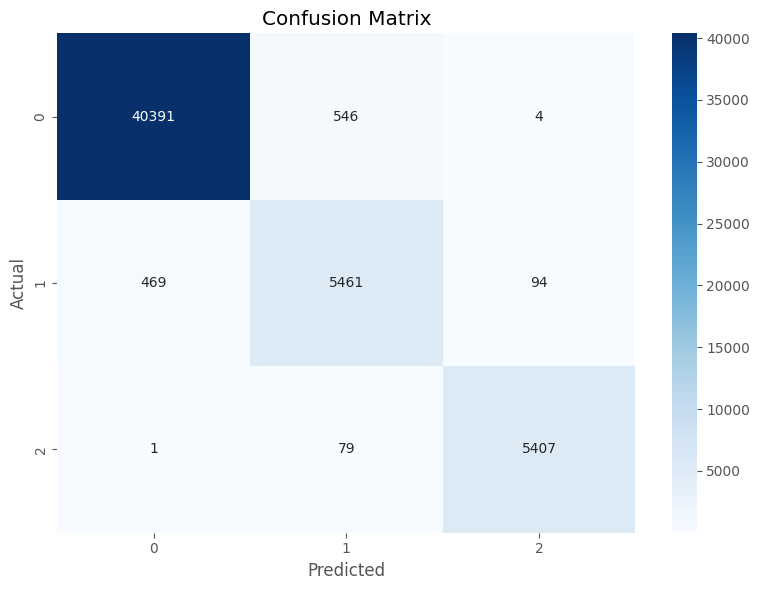

In [37]:
# CONFUSION MATRIX

cm = confusion_matrix(
    y_test_class,
    rf_pred_class
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(
    "./visualizations/confusion_matrix.png"
)

plt.show()

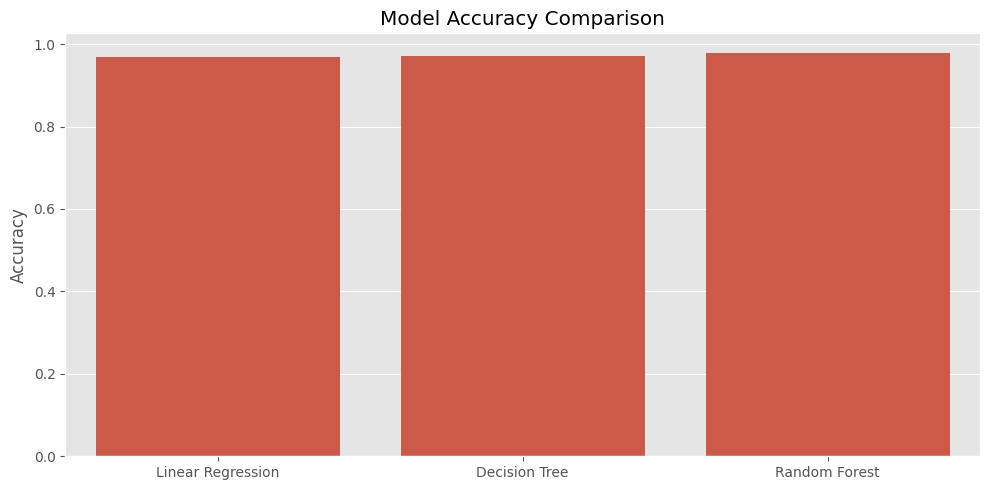

In [38]:
# MODEL COMPARISON

models = [
    "Linear Regression",
    "Decision Tree",
    "Random Forest"
]

accuracies = [
    lr_acc,
    dt_acc,
    rf_acc
]

plt.figure(figsize=(10, 5))

sns.barplot(
    x=models,
    y=accuracies
)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.tight_layout()

plt.savefig(
    "./visualizations/model_comparison.png"
)

plt.show()

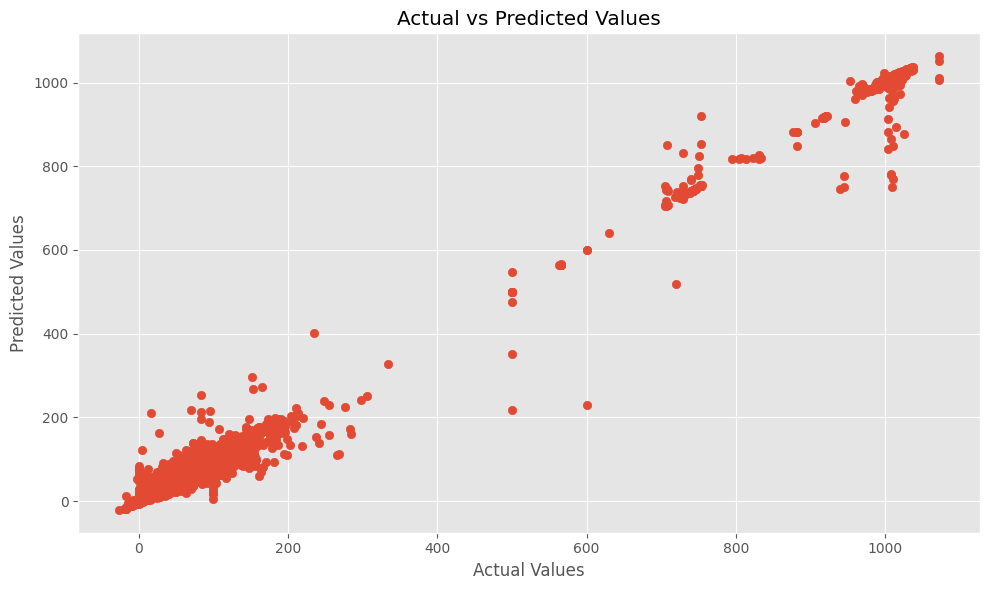

In [39]:
# ACTUAL VS PREDICTED

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    rf_pred
)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted Values")

plt.tight_layout()

plt.savefig(
    "./visualizations/actual_vs_predicted.png"
)

plt.show()

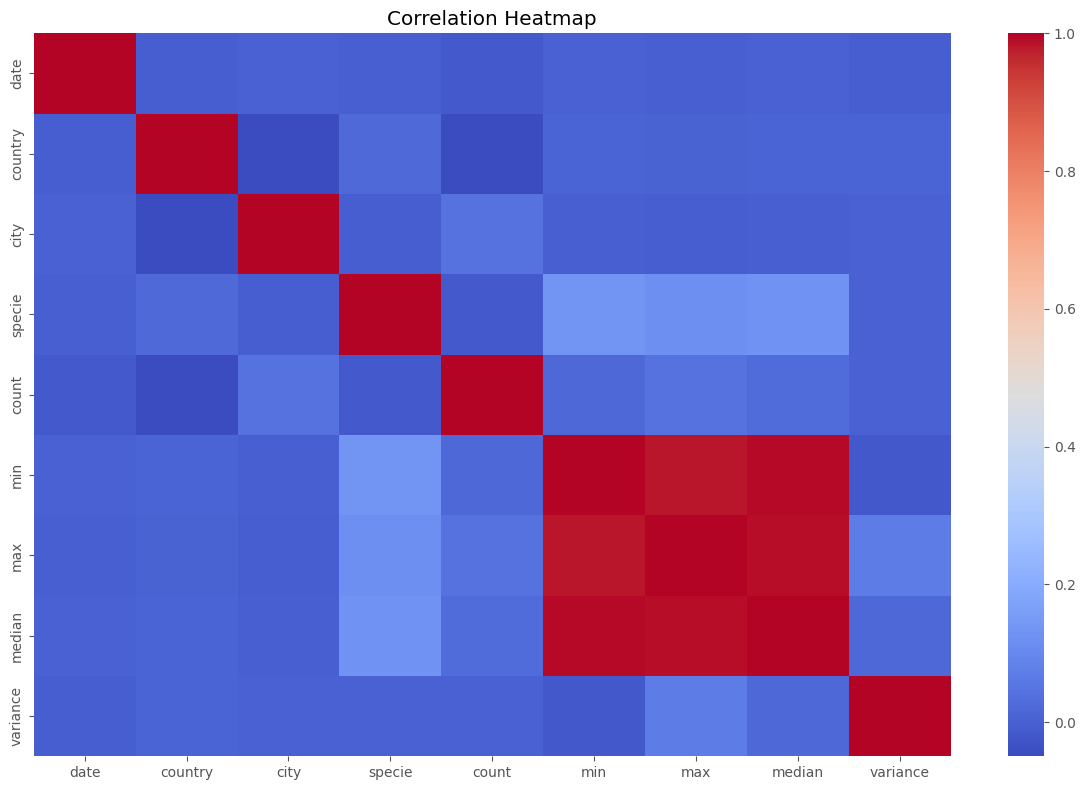

In [41]:
# CORRELATION HEATMAP

plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(),
    cmap='coolwarm',
    annot=False
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    "./visualizations/correlation_heatmap.png"
)

plt.show()

In [42]:
# SAVE DATASET

df.to_csv(
    "../processed_ml_dataset.csv",
    index=False
)

print("\nPROCESSED DATASET SAVED")


PROCESSED DATASET SAVED


In [43]:
# FINAL RESULT

best_accuracy = max(
    lr_acc,
    dt_acc,
    rf_acc
)

if best_accuracy == lr_acc:

    best_model = "Linear Regression"

elif best_accuracy == dt_acc:

    best_model = "Decision Tree"

else:

    best_model = "Random Forest"

print("\nBEST MODEL :", best_model)

print("\nPROJECT COMPLETED SUCCESSFULLY")


BEST MODEL : Random Forest

PROJECT COMPLETED SUCCESSFULLY
